In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df=pd.read_csv(r"FirstStep.csv")
print(df.to_string())

    Unnamed: 0 URL        Date  Engagements  Impressions
0            0   a  2024-03-12            0         1655
1            1   b  2024-06-10           20            0
2            2   c  2024-06-12           15            0
3            3   d  2024-08-12           22         2115
4            4   e  2024-09-11           41         3642
5            5   f  2024-10-15          112        22824
6            6   g  2024-10-20           17            0
7            7   h  2024-10-28           17         2020
8            8   i  2024-10-30           34         4340
9            9   j  2024-11-10          106        15884
10          10   k  2024-11-13           15         3057
11          11   l  2024-11-17           35         7455
12          12   m  2025-01-01           21            0
13          13   n  2025-01-02           42         3792
14          14   o  2025-01-04           54        12910
15          15   p  2025-01-04           17         2020
16          16   q  2025-01-15 

In [3]:
df1=pd.read_excel(r'Book1.xlsx')

In [4]:
total_engagements_df = df['Engagements'].sum()
total_engagements_df1 = df1['Engagements'].sum()

print("Total Engagements in df:", total_engagements_df)
print("Total Engagements in df1:", total_engagements_df1)

Total Engagements in df: 4907
Total Engagements in df1: 4907


In [5]:
total_Impressions_df = df['Impressions'].sum()
total_Impressions_df1 = df1['Impressions'].sum()

print("Total Impressions in df:", total_Impressions_df)
print("Total Impressions in df1:", total_Impressions_df1)

Total Impressions in df: 1239582
Total Impressions in df1: 1239582


In [6]:
df= pd.read_excel('Book2.xlsx')

In [7]:
# Function to convert Excel serial dates to MM/DD/YYYY format
def convert_serial_date(serial):
    try:
        # If the value is already a datetime, format it
        if isinstance(serial, (datetime, pd.Timestamp)):
            return serial.strftime('%m/%d/%Y')
        # If it's a string in MM/DD/YYYY format, return as is
        if isinstance(serial, str) and '/' in serial:
            return serial
        # Convert serial date (numeric) to datetime
        serial = float(serial)
        base_date = datetime(1899, 12, 30)  # Excel's serial date starts from 12/30/1899
        return (base_date + timedelta(days=serial)).strftime('%m/%d/%Y')
    except:
        return None  # Handle invalid dates

In [8]:
# Apply date conversion to the 'Date' column
df['Date'] = df['Date'].apply(convert_serial_date)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values(by='Date')
df['Date'] = df['Date'].dt.strftime('%m/%d/%Y')
df

,Date,Impressions,Engagements
10,01/08/2024,0,0
41,01/09/2024,0,0
71,01/10/2024,2,0
102,01/11/2024,287,1
132,01/12/2024,325,9
...,...,...,...
233,12/03/2025,14785,34
264,12/04/2025,1220,7
294,12/05/2025,598,3
325,12/06/2025,1916,13


In [9]:
# Filter out rows where both Impressions and Engagements are 0
df = df[(df['Impressions'] != 0) | (df['Engagements'] != 0)]
df = df[['Date', 'Impressions', 'Engagements']]
df

,Date,Impressions,Engagements
71,01/10/2024,2,0
102,01/11/2024,287,1
132,01/12/2024,325,9
103,02/11/2024,498,9
133,02/12/2024,466,5
...,...,...,...
233,12/03/2025,14785,34
264,12/04/2025,1220,7
294,12/05/2025,598,3
325,12/06/2025,1916,13


In [10]:
df.reset_index()

,index,Date,Impressions,Engagements
0,71,01/10/2024,2,0
1,102,01/11/2024,287,1
2,132,01/12/2024,325,9
3,103,02/11/2024,498,9
4,133,02/12/2024,466,5
...,...,...,...,...
313,233,12/03/2025,14785,34
314,264,12/04/2025,1220,7
315,294,12/05/2025,598,3
316,325,12/06/2025,1916,13


In [11]:
df= pd.read_csv('Book3.csv')
df

,Date,New followers
0,7/22/2024,0
1,7/23/2024,0
2,7/24/2024,0
3,7/25/2024,1
4,7/26/2024,1
...,...,...
362,7/19/2025,13
363,7/20/2025,3
364,7/21/2025,12
365,7/20/2025,3


In [12]:
df = df[df['New followers'] != 0]
df=df.reset_index(drop=True)
df

,Date,New followers
0,7/25/2024,1
1,7/26/2024,1
2,7/29/2024,1
3,7/30/2024,1
4,7/31/2024,1
...,...,...
325,7/19/2025,13
326,7/20/2025,3
327,7/21/2025,12
328,7/20/2025,3


In [13]:
df['Date'] = df['Date'].str.replace('-', '/', regex=False)

In [14]:
# Function to convert Excel serial dates to MM/DD/YYYY format
def convert_serial_date(serial):
    try:
        # If the value is already a datetime, format it
        if isinstance(serial, (datetime, pd.Timestamp)):
            return serial.strftime('%m/%d/%Y')
        # If it's a string in MM/DD/YYYY format, return as is
        if isinstance(serial, str) and '/' in serial:
            return serial
        # Convert serial date (numeric) to datetime
        serial = float(serial)
        base_date = datetime(1899, 12, 30)  # Excel's serial date starts from 12/30/1899
        return (base_date + timedelta(days=serial)).strftime('%m/%d/%Y')
    except:
        return None

In [15]:
# Apply date conversion to the 'Date' column
df['Date'] = df['Date'].apply(convert_serial_date)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values(by='Date')
df['Date'] = df['Date'].dt.strftime('%m/%d/%Y')
df = df[['Date', 'New followers']]
df

,Date,New followers
0,07/25/2024,1
1,07/26/2024,1
2,07/29/2024,1
3,07/30/2024,1
4,07/31/2024,1
...,...,...
325,07/19/2025,13
326,07/20/2025,3
328,07/20/2025,3
327,07/21/2025,12


In [16]:
df1=pd.read_csv(r'FirstStep.csv')
df2=pd.read_csv(r'SecondStep.csv')
df3=pd.read_csv(r'ThirdStep.csv')

In [17]:
df1

,Unnamed: 0,URL,Date,Engagements,Impressions
0,0,a,2024-03-12,0,1655
1,1,b,2024-06-10,20,0
2,2,c,2024-06-12,15,0
3,3,d,2024-08-12,22,2115
4,4,e,2024-09-11,41,3642
...,...,...,...,...,...
58,58,bg,2025-07-04,27,6762
59,59,bh,2025-07-04,17,0
60,60,bi,2025-07-05,19,0
61,61,bj,2025-09-04,0,2301


In [18]:
df2

,Date,Impressions,Engagements
0,01/10/2024,2,0
1,01/11/2024,287,1
2,01/12/2024,325,9
3,02/11/2024,498,9
4,02/12/2024,466,5
...,...,...,...
313,12/03/2025,14785,34
314,12/04/2025,1220,7
315,12/05/2025,598,3
316,12/06/2025,1916,13


In [19]:
df3

,Date,New followers
0,07/25/2024,1
1,07/26/2024,1
2,07/29/2024,1
3,07/30/2024,1
4,07/31/2024,1
...,...,...
325,07/19/2025,13
326,07/20/2025,3
327,07/20/2025,3
328,07/21/2025,12


In [20]:
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')
df2['Date'] = pd.to_datetime(df2['Date'], errors='coerce')
df3['Date'] = pd.to_datetime(df3['Date'], errors='coerce')

In [21]:
# Format consistently (YYYY-MM-DD)
df1['Date'] = df1['Date'].dt.strftime('%Y-%m-%d')
df2['Date'] = df2['Date'].dt.strftime('%Y-%m-%d')
df3['Date'] = df3['Date'].dt.strftime('%Y-%m-%d')

In [22]:
# Drop posts where BOTH engagements & impressions are 0
df1 = df1[(df1['Impressions'] != 0) | (df1['Engagements'] != 0)]
df2 = df2[(df2['Impressions'] != 0) | (df2['Engagements'] != 0)]

In [23]:
daily = pd.merge(df2, df3, on='Date', how='outer')
daily = daily.fillna(0)  # fill missing with 0

In [24]:
# Fill missing values: 0 for metrics
daily['Impressions'] = daily['Impressions'].fillna(0).astype(int)
daily['Engagements'] = daily['Engagements'].fillna(0).astype(int)
daily['New followers'] = daily['New followers'].fillna(0).astype(int)

In [25]:
# Ensure Date is datetime
daily['Date'] = pd.to_datetime(daily['Date'], errors='coerce')

# Now sort safely
daily = daily.sort_values(by="Date").reset_index(drop=True)

In [26]:
New_followers_df3 = daily['New followers'].sum()
print("Total New followers in df3:", New_followers_df3)
New_Impressions = daily['Impressions'].sum()
print("Total Impressions in df3:", New_Impressions)
New_Engagements = daily['Engagements'].sum()
print("Total Engagements in df3:", New_Engagements)

Total New followers in df3: 4652
Total Impressions in df3: 1318233
Total Engagements in df3: 5748


In [27]:
daily=daily.to_csv('Step4.csv')

In [28]:
df1=pd.read_csv(r'FirstStep.csv')
df2=pd.read_csv(r'Step4.csv')

In [29]:
df2=df2.drop(columns='Unnamed: 0')

In [30]:
df2

,Date,Impressions,Engagements,New followers
0,2024-01-10,2,0,0
1,2024-01-11,287,1,0
2,2024-01-12,325,9,0
3,2024-02-11,498,9,0
4,2024-02-12,466,5,0
...,...,...,...,...
398,2025-12-03,14785,34,0
399,2025-12-04,1220,7,0
400,2025-12-05,598,3,0
401,2025-12-06,1916,13,0


In [31]:
df1

,Unnamed: 0,URL,Date,Engagements,Impressions
0,0,a,2024-03-12,0,1655
1,1,b,2024-06-10,20,0
2,2,c,2024-06-12,15,0
3,3,d,2024-08-12,22,2115
4,4,e,2024-09-11,41,3642
...,...,...,...,...,...
58,58,bg,2025-07-04,27,6762
59,59,bh,2025-07-04,17,0
60,60,bi,2025-07-05,19,0
61,61,bj,2025-09-04,0,2301


In [32]:
# Calculate 80th percentile threshold for daily impressions
viral_threshold = df2['Impressions'].quantile(0.7)

In [33]:
# Prepare list to collect results
result = []

In [34]:
for idx, post in df1.iterrows():
    url = post['URL']
    post_date = post['Date']
    total_impr = post['Impressions']
    total_eng = post['Engagements']
    
    # Filter daily data starting from the post date
    daily_subset = df2[df2['Date'] >= post_date].sort_values('Date')
    
    cum_impr = 0
    cum_eng = 0
    cum_followers = 0
    viral_days_count = 0
    days_count = 0
    
    for _, day in daily_subset.iterrows():
        if cum_impr >= total_impr and cum_eng >= total_eng:
            break
        cum_impr += day['Impressions']
        cum_eng += day['Engagements']
        cum_followers += day['New followers']
        days_count += 1
        if day['Impressions'] >= viral_threshold:
            viral_days_count += 1
            
    result.append({
        'URL': url,
        'Date': post_date,
        'Impressions': total_impr,
        'Engagements': total_eng,
        'Followers': cum_followers,
        'Viral_Days': viral_days_count
    })

In [35]:
final_df = pd.DataFrame(result)

In [36]:
final_df.to_csv("Final_data.")
df=final_df

In [37]:
print(df.to_string())

   URL        Date  Impressions  Engagements  Followers  Viral_Days
0    a  2024-03-12         1655            0          0           2
1    b  2024-06-10            0           20          0           1
2    c  2024-06-12            0           15          0           1
3    d  2024-08-12         2115           22         23           1
4    e  2024-09-11         3642           41          1           2
5    f  2024-10-15        22824          112        115           5
6    g  2024-10-20            0           17         14           1
7    h  2024-10-28         2020           17         30           1
8    i  2024-10-30         4340           34         75           2
9    j  2024-11-10        15884          106         92           7
10   k  2024-11-13         3057           15         16           1
11   l  2024-11-17         7455           35         35           5
12   m  2025-01-01            0           21          3           1
13   n  2025-01-02         3792           42    

In [38]:
# Calculate average new followers for viral posts
viral_posts = df[df['Viral_Days'] == 1]
avg_new_followers_viral = viral_posts['Followers'].mean()

In [39]:
# Calculate average new followers for non-viral posts
non_viral_posts = df[df['Viral_Days'] == 0]
avg_new_followers_non_viral = non_viral_posts['Followers'].mean()

In [40]:
# Calculate increase and percentage increase
increase = avg_new_followers_viral - avg_new_followers_non_viral
percentage_increase = (increase / avg_new_followers_non_viral) * 100

In [41]:
# Print results
print(f"Average new followers (viral posts): {avg_new_followers_viral:.2f}")
print(f"Average new followers (non-viral posts): {avg_new_followers_non_viral:.2f}")
print(f"Increase in new followers after viral posts: {increase:.2f}")
print(f"Percentage increase: {percentage_increase:.2f}%")

Average new followers (viral posts): 46.25
Average new followers (non-viral posts): 22.33
Increase in new followers after viral posts: 23.92
Percentage increase: 107.09%


C:\Users\nitin\AppData\Local\Temp\ipykernel_8136\3336025067.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(avg_followers.keys()), y=list(avg_followers.values()), palette='viridis')


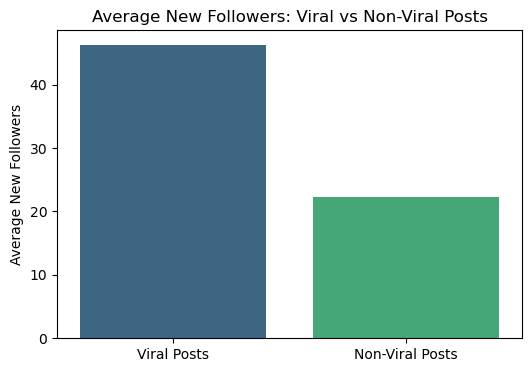

In [42]:
# Data preparation
avg_followers = {
    'Viral Posts': avg_new_followers_viral,
    'Non-Viral Posts': avg_new_followers_non_viral
}

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=list(avg_followers.keys()), y=list(avg_followers.values()), palette='viridis')
plt.title('Average New Followers: Viral vs Non-Viral Posts')
plt.ylabel('Average New Followers')
plt.xlabel('')
plt.show()

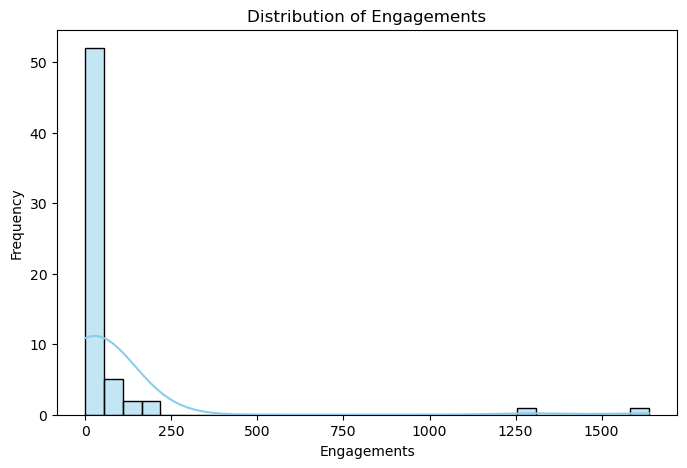

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['Engagements'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Engagements')
plt.xlabel('Engagements')
plt.ylabel('Frequency')
plt.show()

C:\Users\nitin\AppData\Local\Temp\ipykernel_8136\169910977.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(locations.values()), y=list(locations.keys()), palette='magma')


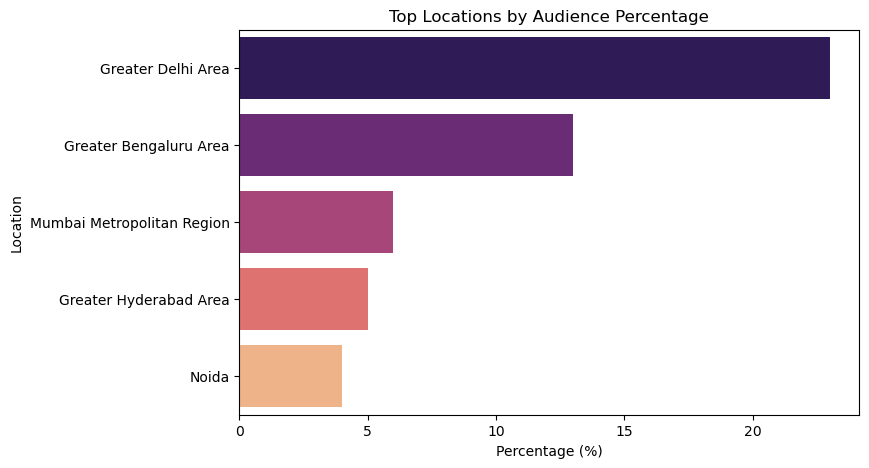

In [44]:
# Sample data for locations (replace with your actual data)
locations = {
    'Greater Delhi Area': 23,
    'Greater Bengaluru Area': 13,
    'Mumbai Metropolitan Region': 6,
    'Greater Hyderabad Area': 5,
    'Noida': 4
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(locations.values()), y=list(locations.keys()), palette='magma')
plt.title('Top Locations by Audience Percentage')
plt.xlabel('Percentage (%)')
plt.ylabel('Location')
plt.show()

C:\Users\nitin\AppData\Local\Temp\ipykernel_8136\799067662.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(job_titles.values()), y=list(job_titles.keys()), palette='coolwarm')


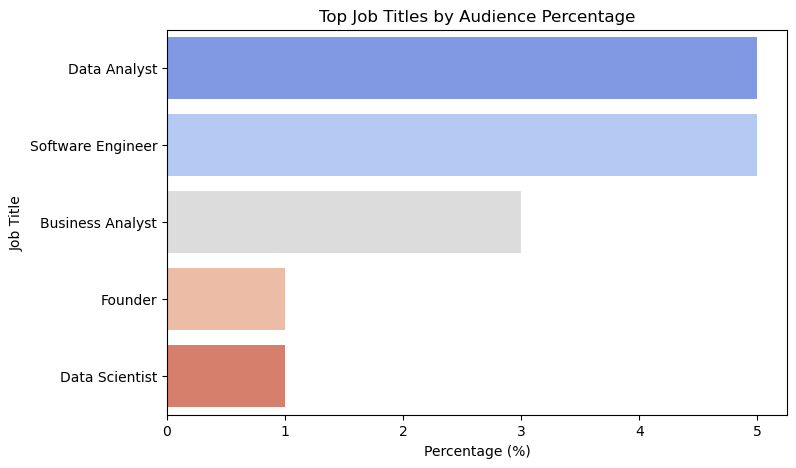

In [45]:
job_titles = {
    'Data Analyst': 5,
    'Software Engineer': 5,
    'Business Analyst': 3,
    'Founder': 1,
    'Data Scientist': 1
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(job_titles.values()), y=list(job_titles.keys()), palette='coolwarm')
plt.title('Top Job Titles by Audience Percentage')
plt.xlabel('Percentage (%)')
plt.ylabel('Job Title')
plt.show()

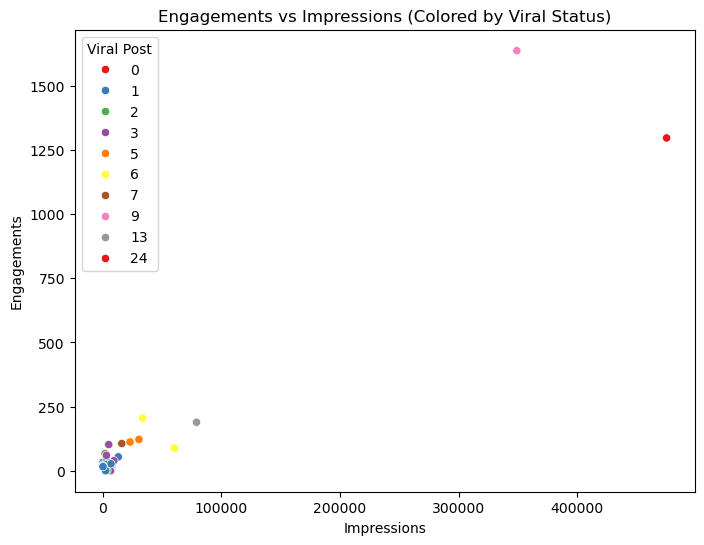

In [46]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Impressions', y='Engagements', hue='Viral_Days', palette='Set1')
plt.title('Engagements vs Impressions (Colored by Viral Status)')
plt.xlabel('Impressions')
plt.ylabel('Engagements')
plt.legend(title='Viral Post')
plt.show()

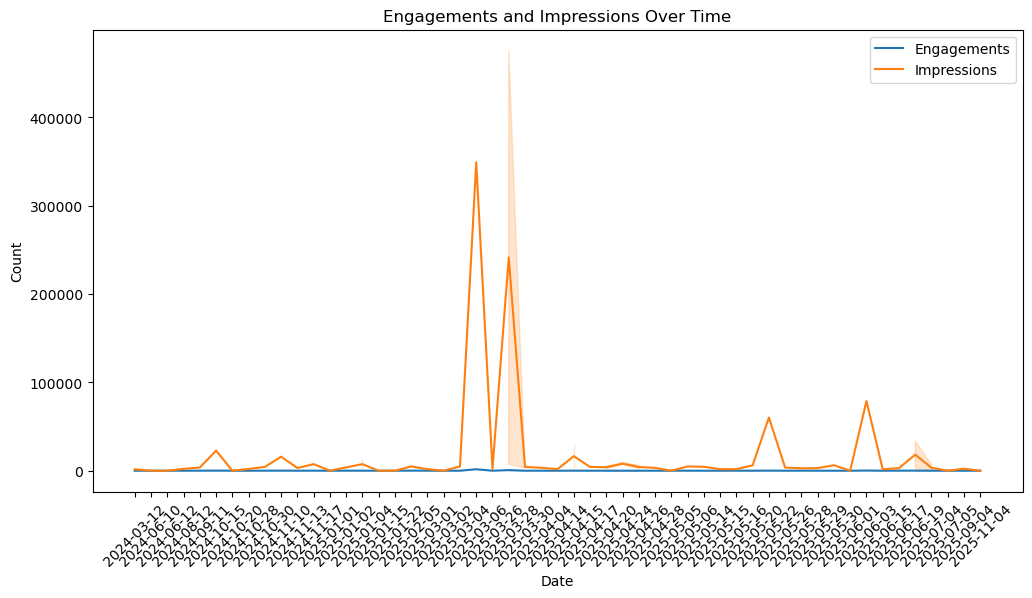

In [47]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Date', y='Engagements', label='Engagements')
sns.lineplot(data=df, x='Date', y='Impressions', label='Impressions')
plt.title('Engagements and Impressions Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.show()

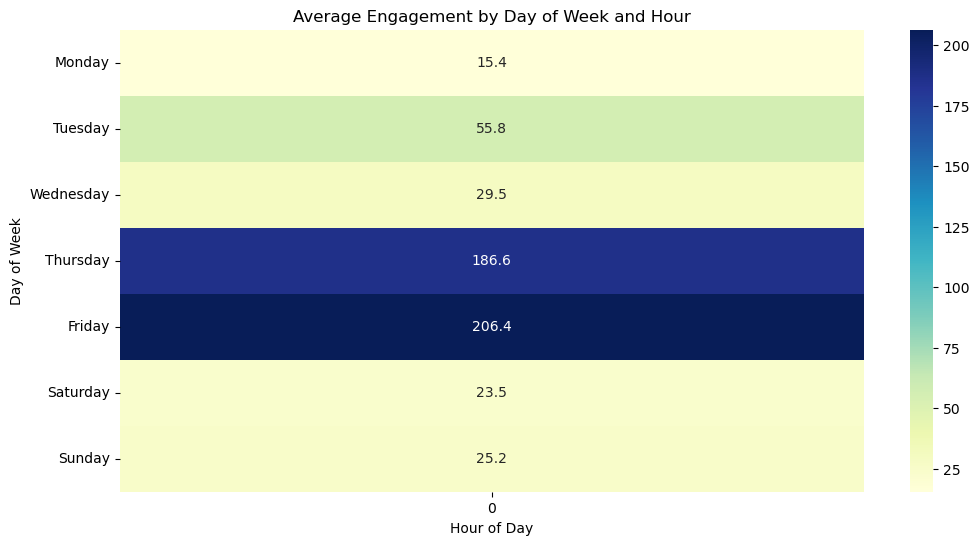

In [48]:
# Assuming 'Date' column is datetime and you have 'Hour' column or can extract it
df['Date'] = pd.to_datetime(df['Date'])
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Hour'] = df['Date'].dt.hour

pivot_table = df.pivot_table(values='Engagements', index='DayOfWeek', columns='Hour', aggfunc='mean').reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt=".1f")
plt.title('Average Engagement by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

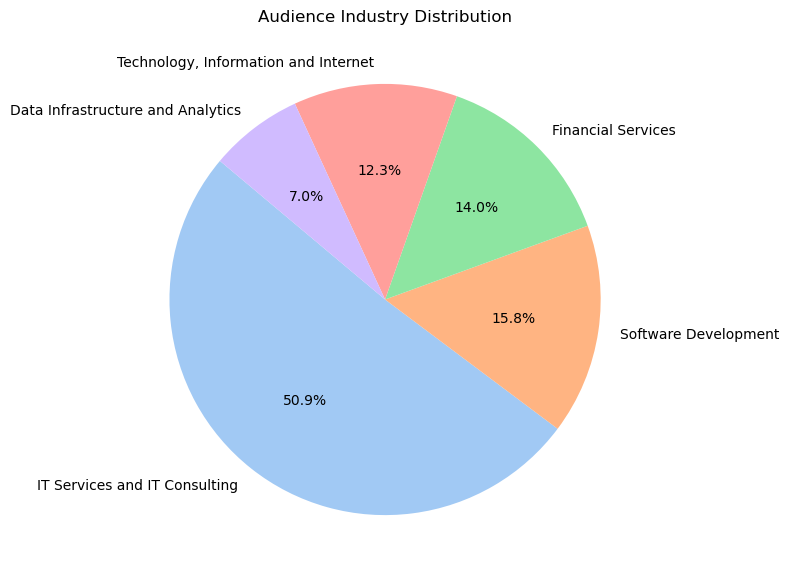

In [49]:
industries = {
    'IT Services and IT Consulting': 29,
    'Software Development': 9,
    'Financial Services': 8,
    'Technology, Information and Internet': 7,
    'Data Infrastructure and Analytics': 4
}

plt.figure(figsize=(7,7))
plt.pie(industries.values(), labels=industries.keys(), autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Audience Industry Distribution')
plt.show()

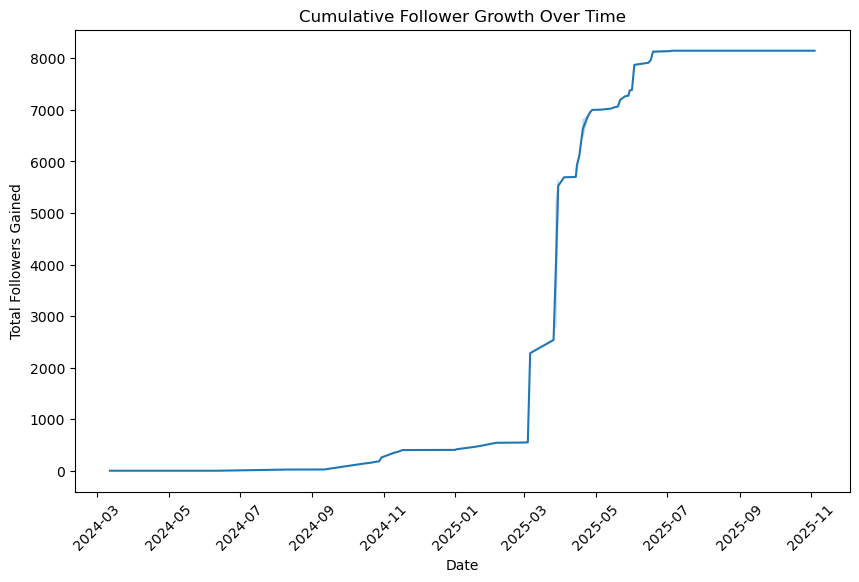

In [50]:
df_sorted = df.sort_values('Date')
df_sorted['Cumulative Followers'] = df_sorted['Followers'].cumsum()

plt.figure(figsize=(10,6))
sns.lineplot(data=df_sorted, x='Date', y='Cumulative Followers')
plt.title('Cumulative Follower Growth Over Time')
plt.xlabel('Date')
plt.ylabel('Total Followers Gained')
plt.xticks(rotation=45)
plt.show()

C:\Users\nitin\AppData\Local\Temp\ipykernel_8136\3864283763.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages, y=sizes, palette='Greens_d')


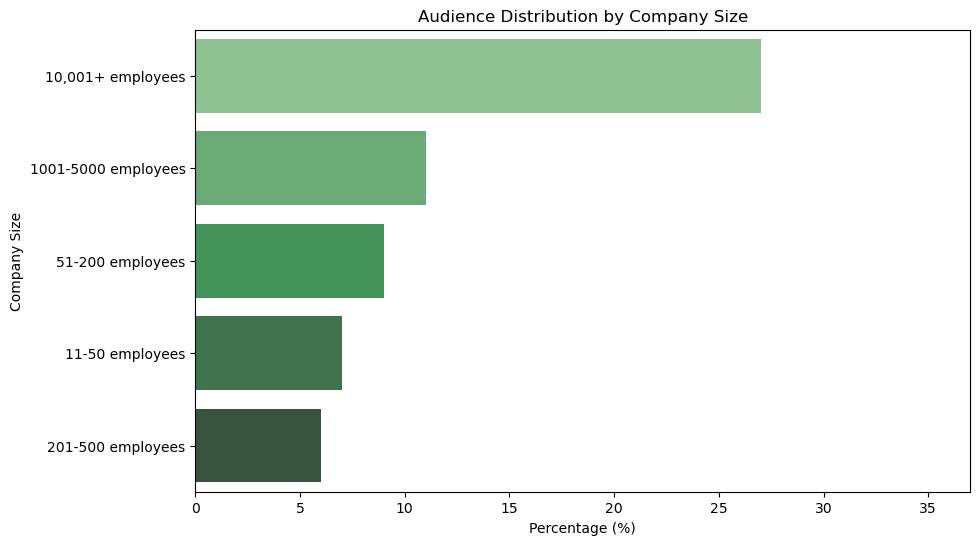

In [51]:
company_size = {
    '10,001+ employees': 27,
    '1001-5000 employees': 11,
    '51-200 employees': 9,
    '11-50 employees': 7,
    '201-500 employees': 6
}

sizes = list(company_size.keys())
percentages = list(company_size.values())

plt.figure(figsize=(10,6))
sns.barplot(x=percentages, y=sizes, palette='Greens_d')
plt.title('Audience Distribution by Company Size')
plt.xlabel('Percentage (%)')
plt.ylabel('Company Size')
plt.xlim(0, max(percentages) + 10)
plt.show()